In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
sys.path.append(".")

In [4]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs import FusekiDB
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
from rdflib.plugins.stores.sparqlstore import SPARQLStore
import rdflib
import numpy as np
from utils.datasets.base_dataset import DataTensor

In [5]:
powers = np.arange(1, 5)
sizes = 10**powers

In [6]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset

2026-03-23 22:53:02,332 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-03-23 22:53:02,333 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-03-23 22:53:02,333 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation
2026-03-23 22:53:02,334 - INFO - BSBM dataset already exists in data/bsbm_4, skipping generation


Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...
Running BDSDM generation for size 10000...


In [7]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

2026-03-23 22:53:02,402 - INFO - Use pytorch device_name: mps
2026-03-23 22:53:02,402 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-03-23 22:53:02,609 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-23 22:53:02,629 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-23 22:53:02,765 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-23 22:53:02,785 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-23 22:53:02,919 - INFO - HTTP R

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-23 22:53:03,965 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-23 22:53:03,983 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-03-23 22:53:04,115 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-23 22:53:04,133 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transfor

In [8]:
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    dataset.encode(encoding_model)

Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10000...
Encoded TTL file already exists at data/bsbm_4/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [9]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label)).to_literal()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
test_tensor.n3()

'"{\\"data\\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436276763677597, -0.028667299076914787, -0.03249424323439598, 0.05894969776272774, -0.0051073539070785046, 0.09506018459796906, -0.02917008101940155, -0.07172351330518723, 0.03642679378390312, 0.017889918759465218, 0.0777449756860733, -0.010582818649709225, -0.027199456468224525, -0.014839813113212585, 0.004996409639716148, -0.05195300653576851, -0.01563340052962303, -0.0004883771180175245, 0.012572054751217365, -0.0434229

In [11]:

base_bsbm_set = datasets[1]
db = FusekiDB(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    build_dir=Path("../jena-datatensor"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
with db:
    test_query = base_bsbm_set.get_queries(
        difficulty=QUERY_DIFFICULTY.HARD,
        query_type=QUERY_TYPE.EMBEDDED,
        embedding=test_tensor,
    )

    results = db.query(test_query)
    print(results)

2026-03-23 22:53:05,621 - INFO - Binding prefix bsbmv to URI http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/vocabulary/
2026-03-23 22:53:05,622 - INFO - Binding prefix bsbmi to URI http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/
2026-03-23 22:53:05,622 - INFO - Building docker image jena-datatensor from ../jena-datatensor
2026-03-23 22:53:06,429 - INFO - Loading dataset into Fuseki server from data/bsbm_1/dataset.nt
2026-03-23 22:53:06,430 - WARNING - DB directory scratch/bsbm/bsbm_1/db already exists, removing locks if any
2026-03-23 22:53:06,431 - INFO - Stopping server with container name fuseki_benchmarks_test
2026-03-23 22:53:06,475 - ERROR - Command failed with return code 1
2026-03-23 22:53:06,526 - INFO - Starting Fuseki server with container name fuseki_benchmarks_test on port 3031
2026-03-23 22:53:08,542 - INFO - Database setup complete, entering context manager
2026-03-23 22:53:08,544 - INFO - Running SPARQL query: 
                    PREFIX rdf: <http://www.w3.or

                           productA                          productB  \
0  bsbmi:dataFromProducer1/Product1  bsbmi:dataFromProducer1/Product3   
1  bsbmi:dataFromProducer1/Product3  bsbmi:dataFromProducer1/Product1   
2  bsbmi:dataFromProducer1/Product6  bsbmi:dataFromProducer1/Product7   
3  bsbmi:dataFromProducer1/Product7  bsbmi:dataFromProducer1/Product6   
4  bsbmi:dataFromProducer1/Product2  bsbmi:dataFromProducer1/Product7   
5  bsbmi:dataFromProducer1/Product2  bsbmi:dataFromProducer1/Product8   
6  bsbmi:dataFromProducer1/Product7  bsbmi:dataFromProducer1/Product2   
7  bsbmi:dataFromProducer1/Product7  bsbmi:dataFromProducer1/Product8   
8  bsbmi:dataFromProducer1/Product8  bsbmi:dataFromProducer1/Product2   
9  bsbmi:dataFromProducer1/Product8  bsbmi:dataFromProducer1/Product7   

                 dist                                            vectorA  \
0  0.9999999403953552  {"Data": [-0.017002638429403305, 0.00807385984...   
1  0.9999999403953552  {"Data": [-0.01700263

## Try some timings!

In [13]:
import timeit
import pandas as pd

timings = []
repetitions = 128
for power, size in zip(powers, sizes):
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    db = FusekiDB(
        id="test",
        base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
        build_dir=Path("../jena-datatensor"),
        dataset=dataset,
        use_encoded_ttl=True,
    )
    with db:
        test_query = dataset.get_queries(
            difficulty=QUERY_DIFFICULTY.EASY,
            query_type=QUERY_TYPE.EMBEDDED,
            embedding=test_tensor,
        )
        for i in tqdm.tqdm(range(repetitions), desc=f"Timing for size {size}"):
            start_time = timeit.default_timer()
            results = db.raw_query(test_query)
            end_time = timeit.default_timer()
            elapsed_time = end_time - start_time
            timings.append(
                {
                    "size": size,
                    "elapsed_time": elapsed_time,
                    "rep": i,
                    "engine": db.name,
                }
            )
timings_df = pd.DataFrame(timings)
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)


2026-03-23 22:53:28,779 - INFO - Binding prefix bsbmv to URI http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/vocabulary/
2026-03-23 22:53:28,780 - INFO - Binding prefix bsbmi to URI http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/
2026-03-23 22:53:28,780 - INFO - Building docker image jena-datatensor from ../jena-datatensor


Running BDSDM timing for size 10...


2026-03-23 22:53:29,073 - INFO - Loading dataset into Fuseki server from data/bsbm_1/dataset.nt
2026-03-23 22:53:29,074 - WARNING - DB directory scratch/bsbm/bsbm_1/db already exists, removing locks if any
2026-03-23 22:53:29,075 - INFO - Stopping server with container name fuseki_benchmarks_test
2026-03-23 22:53:29,104 - ERROR - Command failed with return code 1
2026-03-23 22:53:29,137 - INFO - Starting Fuseki server with container name fuseki_benchmarks_test on port 3031
2026-03-23 22:53:31,153 - INFO - Database setup complete, entering context manager
Timing for size 10:   0%|          | 0/128 [00:00<?, ?it/s]2026-03-23 22:53:31,161 - INFO - Running SPARQL query: 
    PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
    PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
    PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
    SELECT ?product  ?vector ?dist
    WHERE {
        ?product rdf:label_emb

Running BDSDM timing for size 100...


2026-03-23 22:53:37,623 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-03-23 22:53:37,624 - WARNING - DB directory scratch/bsbm/bsbm_2/db already exists, removing locks if any
2026-03-23 22:53:37,625 - INFO - Stopping server with container name fuseki_benchmarks_test
2026-03-23 22:53:37,659 - ERROR - Command failed with return code 1
2026-03-23 22:53:37,692 - INFO - Starting Fuseki server with container name fuseki_benchmarks_test on port 3031
2026-03-23 22:53:39,711 - INFO - Database setup complete, entering context manager
Timing for size 100:   0%|          | 0/128 [00:00<?, ?it/s]2026-03-23 22:53:39,715 - INFO - Running SPARQL query: 
    PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
    PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
    PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
    SELECT ?product  ?vector ?dist
    WHERE {
        ?product rdf:label_em

Running BDSDM timing for size 1000...


2026-03-23 22:53:48,971 - INFO - Loading dataset into Fuseki server from data/bsbm_3/dataset.nt
2026-03-23 22:53:48,972 - WARNING - DB directory scratch/bsbm/bsbm_3/db already exists, removing locks if any
2026-03-23 22:53:48,973 - INFO - Stopping server with container name fuseki_benchmarks_test
2026-03-23 22:53:49,002 - ERROR - Command failed with return code 1
2026-03-23 22:53:49,030 - INFO - Starting Fuseki server with container name fuseki_benchmarks_test on port 3031
2026-03-23 22:53:51,045 - INFO - Database setup complete, entering context manager
Timing for size 1000:   0%|          | 0/128 [00:00<?, ?it/s]2026-03-23 22:53:51,050 - INFO - Running SPARQL query: 
    PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
    PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
    PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
    SELECT ?product  ?vector ?dist
    WHERE {
        ?product rdf:label_e

Running BDSDM timing for size 10000...


2026-03-23 22:54:18,313 - INFO - Loading dataset into Fuseki server from data/bsbm_4/dataset.nt
2026-03-23 22:54:18,315 - WARNING - DB directory scratch/bsbm/bsbm_4/db already exists, removing locks if any
2026-03-23 22:54:18,316 - INFO - Stopping server with container name fuseki_benchmarks_test
2026-03-23 22:54:18,354 - ERROR - Command failed with return code 1
2026-03-23 22:54:18,382 - INFO - Starting Fuseki server with container name fuseki_benchmarks_test on port 3031
2026-03-23 22:54:20,395 - INFO - Database setup complete, entering context manager
Timing for size 10000:   0%|          | 0/128 [00:00<?, ?it/s]2026-03-23 22:54:20,398 - INFO - Running SPARQL query: 
    PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
    PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
    PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
    SELECT ?product  ?vector ?dist
    WHERE {
        ?product rdf:label_

In [14]:
groupings = timings_df.groupby(["size", "engine"])["elapsed_time"]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

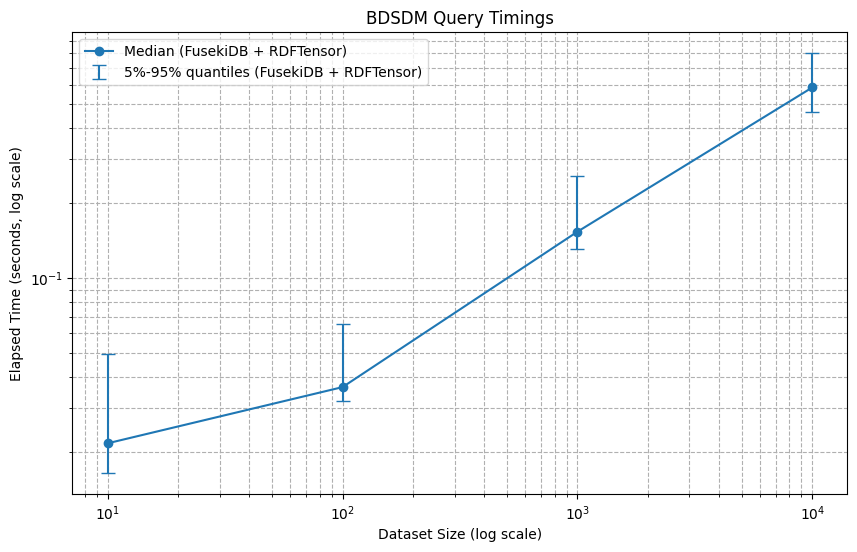

In [15]:
import matplotlib.pyplot as plt

# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
plt.figure(figsize=(10, 6))
for engine in median_timings["engine"].unique():
    engine_median = median_timings[median_timings["engine"] == engine]
    engine_quantiles = quantile_timings[quantile_timings["engine"] == engine]
    plt.plot(median_timings["size"], median_timings["elapsed_time"], "o-", label=f"Median ({engine})    ")
    plt.errorbar(
        engine_median["size"],
        engine_median["elapsed_time"],
        yerr=[
            engine_median["elapsed_time"] - engine_quantiles[0.05],
            engine_quantiles[0.95] - engine_median["elapsed_time"],
        ],
        barsabove=True,
        capsize=5,
        fmt="none",
        label=f"5%-95% quantiles ({engine})",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Dataset Size (log scale)")
plt.ylabel("Elapsed Time (seconds, log scale)")
plt.title("BDSDM Query Timings")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()

In [ ]:
import numpy as np
import faiss

# N = 10000
# quantizer = faiss.IndexFlatIP(N)  # the other index
# index = faiss.IndexIVFFlat(quantizer, N, 100)
# data = []
# for i in range(N):
#     vec = np.zeros(N, dtype=np.float64) + 0.001 * np.random.rand(N)
#     vec[i] = 1.0
#     data.append(vec)
# data = np.array(data)
# index.train(data)
# index.add(data)

2026-03-23 22:34:25,099 - INFO - Loading faiss.
2026-03-23 22:34:25,136 - INFO - Successfully loaded faiss.


In [ ]:
# query_vec = np.zeros(N, dtype=np.float64)
# query_vec[12] = 1.0
# D, I = index.search(query_vec[None, :], 100)
# print("Distances:", D)
# print("Indices:", I)